### From the sunpy example 
https://docs.sunpy.org/en/stable/generated/gallery/plotting/solar_cycle_example.html

In [1]:
#Imports
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.time import Time, TimeDelta
from astropy.visualization import time_support

import sunpy.timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a
from sunpy.time import TimeRange

import numpy as np
import pandas as pd

/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# get data
time_range = TimeRange("1994-01-01 00:00", Time.now()) # I've used the start of the year before the C23 minimum that Tindale and Chapman (2017) use
result = Fido.search(a.Time(time_range), a.Instrument('noaa-indices')) # fido search for the noaa indices in the time range
f_noaa_indices = Fido.fetch(result)
result = Fido.search(a.Time(time_range.end, time_range.end + TimeDelta(4 * u.year)),
                     a.Instrument('noaa-predict')) # get the predicted sunspot numbers from NOAA (4 years in future)
f_noaa_predict = Fido.fetch(result)

Files Downloaded: 100%|██████████| 1/1 [00:00<00:00, 51.28file/s]
/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  6.55file/s]


In [3]:
#loading data into TimeSeries objects
noaa = ts.TimeSeries(f_noaa_indices, source='noaaindices').truncate(time_range) 
noaa_predict = ts.TimeSeries(f_noaa_predict, source='noaapredictindices')

/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
2026-09-03 09:30:13 - sunpy - WARNING: SunpyUserWarning: Unknown units for high25_ssn
2026-09-03 09:30:13 - sunpy - WARNING: SunpyUserWarning: Unknown units for high75_ssn
2026-09-03 09:30:13 - sunpy - WARNING: SunpyUserWarning: Unknown units for low25_ssn
2026-09-03 09:30:13 - sunpy - WARNING: SunpyUserWarning: Unknown units for low75_ssn
2026-09-03 09:30:13 - sunpy - WARNING: SunpyUserWarning: Unknown units for high25_f10.7
2026-09-03 09:30:13 - sunpy - WARNING: SunpyUserWarning: Unknown units for high75_f10.7
2026-09-03 09:30:13 - sunp

In [4]:
TitleSize = 25
AxisSize = 20
TickSize = 15

/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


<bound method GenericTimeSeries.quantity of <sunpy.timeseries.sources.noaa.NOAAIndicesTimeSeries object at 0x7b4a64c72520>
SunPy TimeSeries
----------------
Observatory:			Unknown
Instrument:			<a href=https://www.swpc.noaa.gov/products/solar-cycle-progression target="_blank">Unknown</a>
Channel(s):			sunspot RI<br>sunspot RI smooth<br>sunspot SWO<br>sunspot SWO smooth<br>radio flux<br>radio flux smooth
Start Date:			1996-05-01 00:00:00
End Date:			1996-05-01 00:00:00
Center Date:			1996-05-01 00:00:00
Resolution:			0.0 s
Samples per Channel:		1
Data Range(s):		sunspot RI           0.00E+00<br>sunspot RI smooth    0.00E+00<br>sunspot SWO               NaN<br>sunspot SWO smooth        NaN<br>radio flux                NaN<br>radio flux smooth         NaN
Units:			dimensionless<br>W / (Hz m2)
            sunspot RI  sunspot RI smooth  sunspot SWO  sunspot SWO smooth  \
1996-05-01         7.6               11.2          NaN                 NaN   

            radio flux  radio flux smooth 

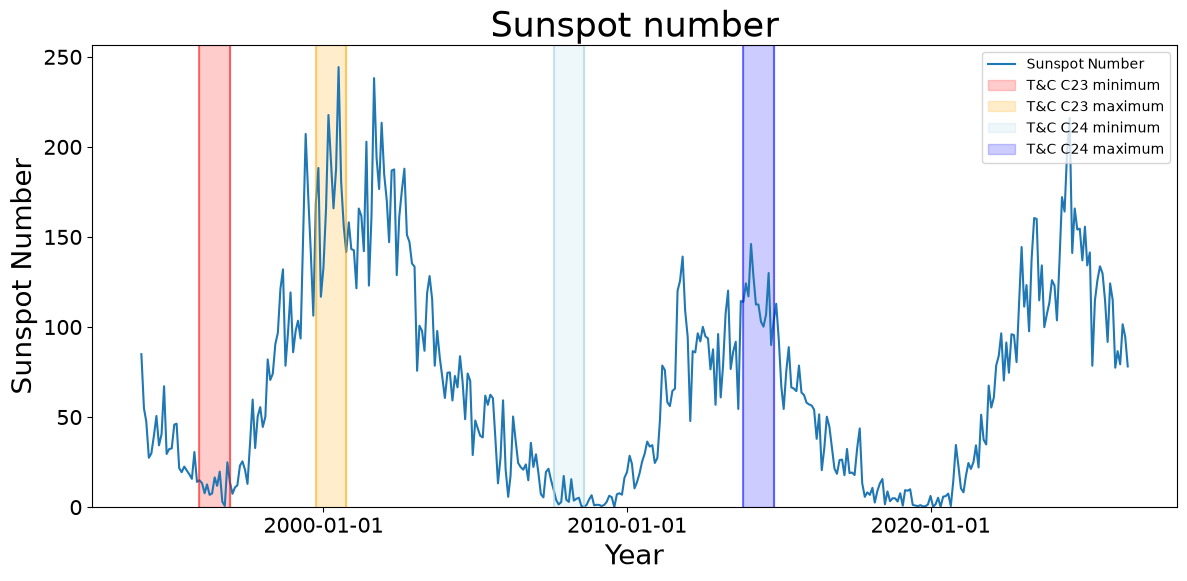

In [5]:
time_support()
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(noaa.time, noaa.quantity('sunspot RI'), label='Sunspot Number')
# ax.plot(
#     noaa_predict.time, noaa_predict.quantity('sunspot'),
#     color='grey', label='Near-term Prediction'
# )
# ax.fill_between(
#     noaa_predict.time, noaa_predict.quantity('sunspot low'),
#     noaa_predict.quantity('sunspot high'), alpha=0.3, color='grey'
# )
ax.set_ylim(bottom=0)
ax.set_ylabel('Sunspot Number', fontsize=AxisSize)
ax.set_xlabel('Year', fontsize=AxisSize)

# times = []
# for t in range(10):
#     times.append(Time('1994-01-01').jd1-2400000 + 4*t*( (Time('1996-01-01').jd1-2400000) - (Time('1995-01-01').jd1-2400000) ) )
# plt.xticks(times, fontsize=TickSize)

plt.xticks(fontsize=TickSize)
plt.yticks(fontsize=TickSize)
plt.title("Sunspot number", fontsize=TitleSize)

# print(noaa.time[0])

#Tindale and Chapman - "These dates were chosen based on the sunspot number, as in Hush et al. (2015)."

#C23 - Min
ax.axvline(Time('1995-12-01').jd1-2400000, color='red', alpha = 0.5)
ax.axvline(Time('1996-11-30').jd1-2400000, color='red', alpha = 0.5)
ax.axvspan(Time('1995-12-01').jd1-2400000, Time('1996-11-30').jd1-2400000, color='red', alpha=0.2, label = "T&C C23 minimum")
C23MinMidtimerange = TimeRange("1996-05-01", "1996-05-31") # I've used the start of the year before the C23 minimum that Tindale and Chapman (2017) use
C23MinMid = ts.TimeSeries(f_noaa_indices, source='noaaindices').truncate(C23MinMidtimerange)
# C23Mintime_range = TimeRange("1995-12-01", "1996-11-30") # I've used the start of the year before the C23 minimum that Tindale and Chapman (2017) use
# C23Minimum = ts.TimeSeries(f_noaa_indices, source='noaaindices').truncate(C23Mintime_range)
print(C23MinMid.quantity) 
# ax.axvline(Time('1996-05-01').jd1-2400000, color='red')

#C23 - Max
ax.axvline(Time('1999-10-01').jd1-2400000, color='orange', alpha = 0.5)
ax.axvline(Time('2000-09-30').jd1-2400000, color='orange', alpha = 0.5)
ax.axvspan(Time('1999-10-01').jd1-2400000, Time('2000-09-30').jd1-2400000, color='orange', alpha=0.2, label = "T&C C23 maximum")

# C24 - Min
ax.axvline(Time('2007-08-01').jd1-2400000, color='lightblue', alpha = 0.7)
ax.axvline(Time('2008-07-31').jd1-2400000, color='lightblue', alpha = 0.7)
ax.axvspan(Time('2007-08-01').jd1-2400000, Time('2008-07-31').jd1-2400000, color='lightblue', alpha=0.2, label = "T&C C24 minimum")

#C24 - Max
ax.axvline(Time('2013-11-01').jd1-2400000, color='blue', alpha = 0.5)
ax.axvline(Time('2014-10-31').jd1-2400000, color='blue', alpha = 0.5)
ax.axvspan(Time('2013-11-01').jd1-2400000, Time('2014-10-31').jd1-2400000, color='blue', alpha=0.2, label = "T&C C24 maximum")

ax.legend()
plt.show()

In [6]:
Start  = "1996-01-01 00:00" # from SIDC
End  = "2026-12-31 23:59" 

def Yearly(startDate, endDate): #ReadDatesForFileFinding
    YearlyRange = pd.date_range(startDate, endDate, freq='YS').strftime("%Y%m%d").tolist()
    return YearlyRange

YearlyRange = Yearly(Start, End)
print(YearlyRange)

StartAndEnd = []
for i in range(len(YearlyRange)-1):
    StartDate = YearlyRange[i]
    EndDate = YearlyRange[i][0:4] + "1231"
    # print(StartDate, EndDate)
    StartAndEnd.append([StartDate[0:4] + "-" + StartDate[4:6] + "-" + StartDate[6:8], EndDate[0:4] + "-" + EndDate[4:6] + "-" + EndDate[6:8]])

print(StartAndEnd)

['19960101', '19970101', '19980101', '19990101', '20000101', '20010101', '20020101', '20030101', '20040101', '20050101', '20060101', '20070101', '20080101', '20090101', '20100101', '20110101', '20120101', '20130101', '20140101', '20150101', '20160101', '20170101', '20180101', '20190101', '20200101', '20210101', '20220101', '20230101', '20240101', '20250101', '20260101']
[['1996-01-01', '1996-12-31'], ['1997-01-01', '1997-12-31'], ['1998-01-01', '1998-12-31'], ['1999-01-01', '1999-12-31'], ['2000-01-01', '2000-12-31'], ['2001-01-01', '2001-12-31'], ['2002-01-01', '2002-12-31'], ['2003-01-01', '2003-12-31'], ['2004-01-01', '2004-12-31'], ['2005-01-01', '2005-12-31'], ['2006-01-01', '2006-12-31'], ['2007-01-01', '2007-12-31'], ['2008-01-01', '2008-12-31'], ['2009-01-01', '2009-12-31'], ['2010-01-01', '2010-12-31'], ['2011-01-01', '2011-12-31'], ['2012-01-01', '2012-12-31'], ['2013-01-01', '2013-12-31'], ['2014-01-01', '2014-12-31'], ['2015-01-01', '2015-12-31'], ['2016-01-01', '2016-12-31

# Yearly

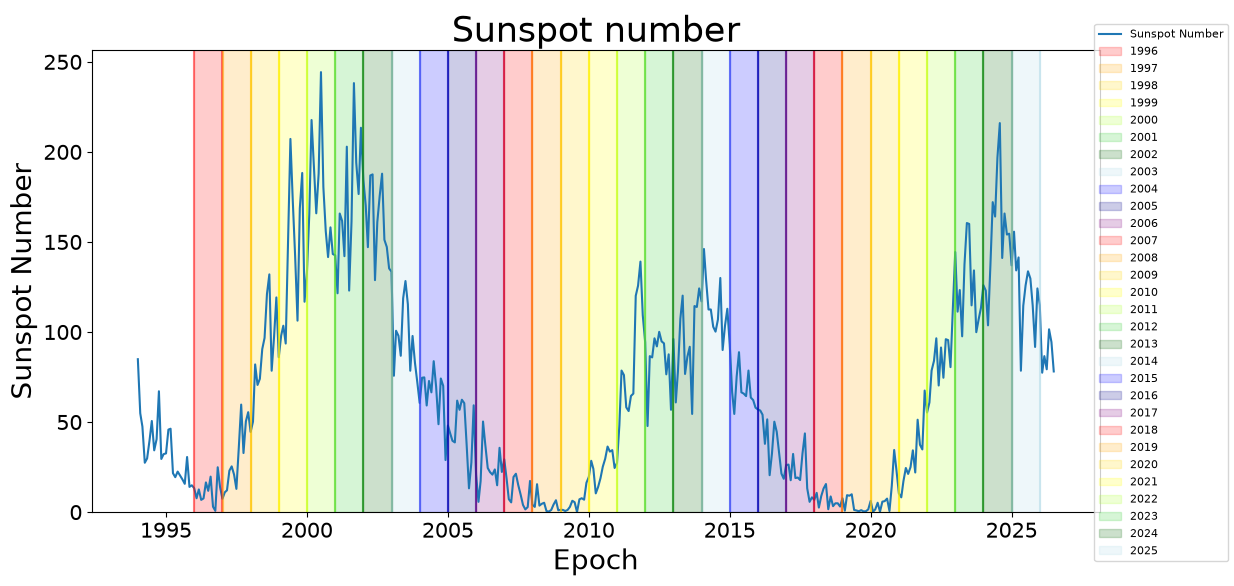

In [11]:
time_support()
fig, ax = plt.subplots(figsize=(13,6))
ax.plot(noaa.time, noaa.quantity('sunspot RI'), label='Sunspot Number')

import datetime as date
times = [date.datetime(1995,1,1), date.datetime(2000,1,1), date.datetime(2005,1,1), date.datetime(2010,1,1), date.datetime(2015,1,1), date.datetime(2020,1,1), date.datetime(2025,1,1)]
t_yr = [tm.year for tm in times]
t=Time(times, format='datetime')
ax.set_xticks(t,t_yr)

# from astropy.time import Time
# import datetime as date
# times = [date.datetime(1996,1,1), date.datetime(1997,1,1)]
# t = Time(times, format='datetime')#, scale='utc')
# # print(t.decimalyear(precision=2))
# plt.xticks(t, rotation=45)
# # ax.get_xticks


# print(str(noaa.time[0])[0:4])
# print(type(noaa.time))

# dfYears = pd.DataFrame({'Date':noaa.time, 'Sunspots':noaa.quantity('sunspot RI')})
# years = []
# for j in range(len(noaa.time)):
#     years.append(str(noaa.time[j])[0:4])

# Set = set(years)
# Years = list(Set)
# from datetime import date
# YearsTime = []
# for k in range(len(Years)):
#     YearsTime.append(date(int(Years[k]), 1, 1))
# print(YearsTime)

# plt.xticks(YearsTime, rotation=45)
# # print(type(noaa.time[0]))
# jyear = np.linspace(2000, 2001, 20)
# t = Time(jyear, format='jyear', scale='utc')
# # fig, ax = plt.subplots()
# ax.xaxis.axis_date()
# fig.autofmt_xdate()  # orient date labels at a slant

# years = [date.year for date in df['Date']]

# plt.xticks(df['Date'], years, rotation=45)

# ax.xaxis.axis_date()

ax.set_ylim(bottom=0)
ax.set_ylabel('Sunspot Number', fontsize=AxisSize)
ax.set_xlabel('Epoch', fontsize=AxisSize)

plt.xticks(fontsize=TickSize)
plt.yticks(fontsize=TickSize)
plt.title("Sunspot number", fontsize=TitleSize)

dateRanges = []
for i in range(len(StartAndEnd)):
    dateRanges.append([Time(StartAndEnd[i][0]).jd1-2400000, Time(StartAndEnd[i][1]).jd1-2400000])

# Colour = ['pink','brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet','gold', 'pink','brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink'] # need 30
Colours = ["red", "orange", "gold", "yellow", "greenyellow", "limegreen", "darkgreen", "lightblue", "blue", "darkblue", "purple", "red", "orange", "gold", "yellow", "greenyellow", "limegreen", "darkgreen", "lightblue", "blue", "darkblue", "purple", "red", "orange", "gold", "yellow", "greenyellow", "limegreen", "darkgreen", "lightblue", "blue", "darkblue", "purple"]

for i in range(len(dateRanges)):
    # print(len(dateRanges))
    ax.axvline(dateRanges[i][0], color=Colours[i], alpha = 0.5)
    # ax.axvspan(dateRanges[i][0], dateRanges[i][1], color=Colours[i], alpha=0.2, label = StartAndEnd[i][0] + "->" + StartAndEnd[i][1])
    ax.axvspan(dateRanges[i][0], dateRanges[i][1], color=Colours[i], alpha=0.2, label = StartAndEnd[i][0][0:4])
    ax.axvline(dateRanges[i][1], color=Colours[i], alpha = 0.5)

# TandCAlpha = 1
# TandCAlpha2 = 0.7
# TandCPosition1 = 0
# TandCPosition2 = 0.05

#Tindale and Chapman - "These dates were chosen based on the sunspot number, as in Hush et al. (2015)."
# ax.axvspan(Time('1995-12-01').jd1-2400000, Time('1996-11-30').jd1-2400000, TandCPosition1, TandCPosition2, color='grey', alpha=TandCAlpha)#, label = "T&C C23 minimum")
# ax.axvspan(Time('1999-10-01').jd1-2400000, Time('2000-09-30').jd1-2400000, TandCPosition1, TandCPosition2, color='grey', alpha=TandCAlpha)#, label = "T&C C23 maximum")
# ax.axvspan(Time('2007-08-01').jd1-2400000, Time('2008-07-31').jd1-2400000, TandCPosition1, TandCPosition2, color='grey', alpha=TandCAlpha)#, label = "T&C C24 minimum")
# ax.axvspan(Time('2013-11-01').jd1-2400000, Time('2014-10-31').jd1-2400000, TandCPosition1, TandCPosition2, color='grey', alpha=TandCAlpha)#, label = "T&C C24 maximum")

# C23MinMidtimerange = TimeRange("1996-05-01", "1996-05-31") # I've used the start of the year before the C23 minimum that Tindale and Chapman (2017) use
# C23MinMid = ts.TimeSeries(f_noaa_indices, source='noaaindices').truncate(C23MinMidtimerange)
# # C23Mintime_range = TimeRange("1995-12-01", "1996-11-30") # I've used the start of the year before the C23 minimum that Tindale and Chapman (2017) use
# # C23Minimum = ts.TimeSeries(f_noaa_indices, source='noaaindices').truncate(C23Mintime_range)
# print(C23MinMid.quantity) 
# ax.axvline(Time('1996-05-01').jd1-2400000, color='red')

fig.legend(loc="outside right", fontsize=8)
plt.savefig("YearlySunspotNumber.png")
plt.show()